In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:
# Load training & validation Data
train_data_path = "../Data/week5_wide_data.csv"
val_data_path = "../Data/val_data.csv"

train_df = pd.read_csv(train_data_path)
val_df = pd.read_csv(val_data_path)

# Convert validation data to wide format
val_df_grouped = val_df.groupby(["country_name", "year", "series_name"], as_index=False)["value"].mean()
val_df_wide = val_df_grouped.pivot(index=["country_name", "year"], columns="series_name", values="value").reset_index()
val_df_wide.columns.name = None

# Define target variable
target_variable = "Life expectancy at birth, total (years)"

# Define features and exclude non numeric & target column
feature_columns = [col for col in train_df.columns if col not in ["country_name", "year", target_variable]]
common_features = list(set(feature_columns) & set(val_df_wide.columns))

# Prepare training and validation data
X_train, y_train = train_df[common_features], train_df[target_variable]
X_val, y_val = val_df_wide[common_features], val_df_wide[target_variable]

# Fill missing values if any
X_train.fillna(X_train.mean(), inplace=True)
X_val.fillna(X_val.mean(), inplace=True)


/var/folders/z6/vcd1nm395kx4c8bz82wk7hdw0000gn/T/ipykernel_4862/2528749635.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.fillna(X_train.mean(), inplace=True)
/var/folders/z6/vcd1nm395kx4c8bz82wk7hdw0000gn/T/ipykernel_4862/2528749635.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val.fillna(X_val.mean(), inplace=True)


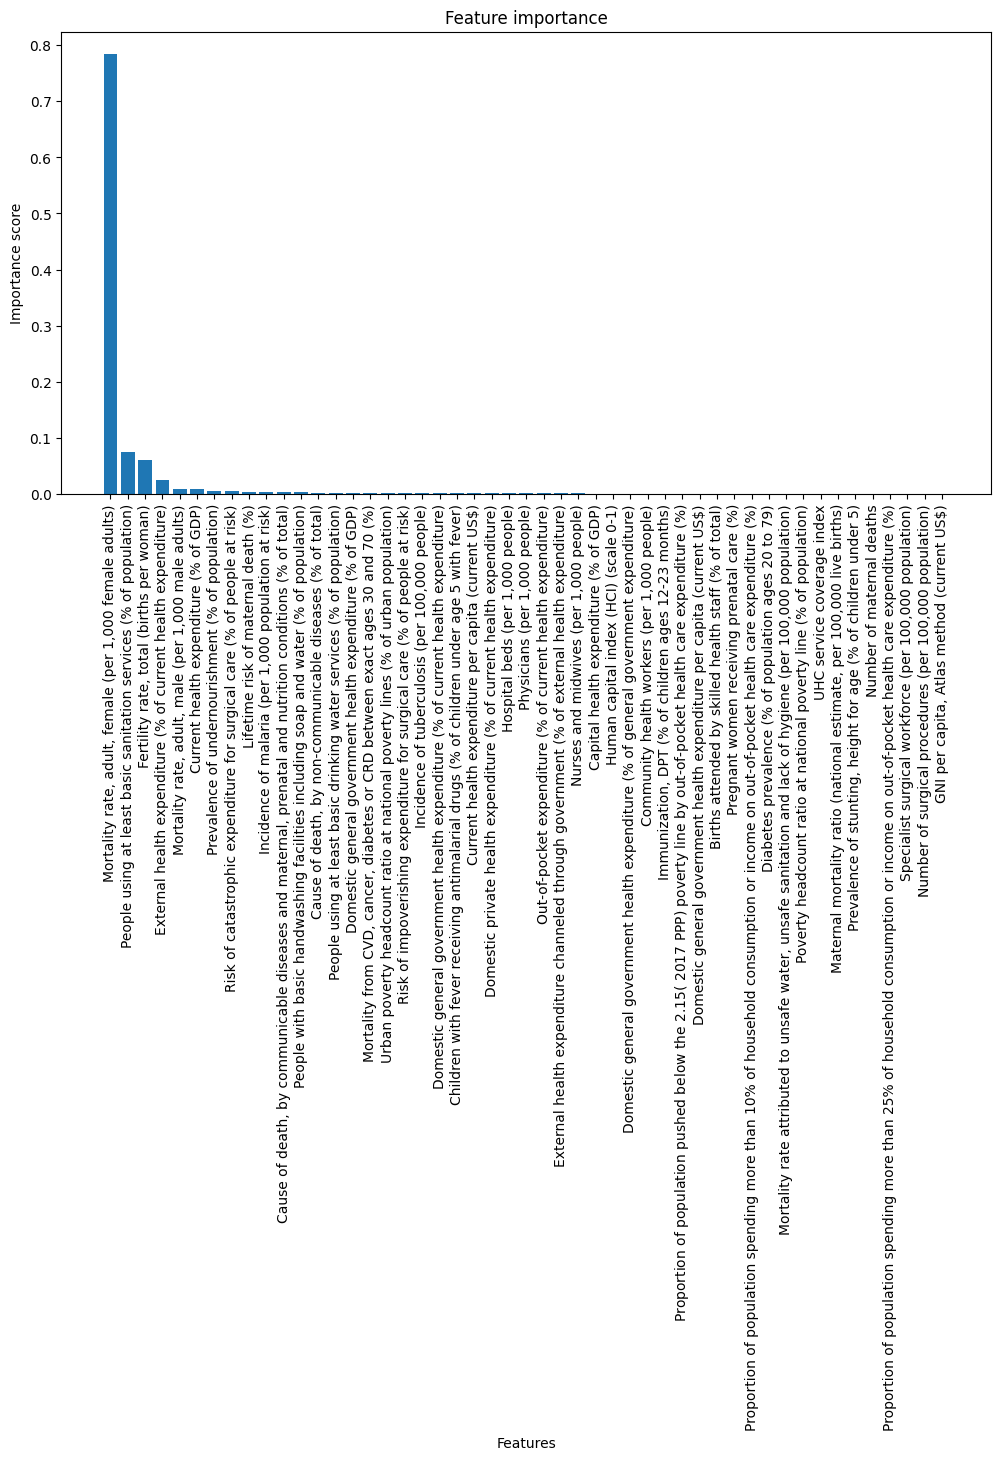

Mortality rate, adult, female (per 1,000 female adults)                     0.785045
People using at least basic sanitation services (% of population)           0.073810
Fertility rate, total (births per woman)                                    0.059869
External health expenditure (% of current health expenditure)               0.023718
Mortality rate, adult, male (per 1,000 male adults)                         0.008610
Current health expenditure (% of GDP)                                       0.008318
Prevalence of undernourishment (% of population)                            0.005085
Risk of catastrophic expenditure for surgical care (% of people at risk)    0.004630
Lifetime risk of maternal death (%)                                         0.003848
Incidence of malaria (per 1,000 population at risk)                         0.003763
dtype: float64


In [3]:
# Feature importance analysis
rf_temp = RandomForestRegressor(n_estimators=50, random_state=42)
rf_temp.fit(X_train, y_train)

feature_importance = rf_temp.feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_importance)), feature_importance[sorted_idx], align="center")
plt.xticks(range(len(feature_importance)), np.array(X_train.columns)[sorted_idx], rotation=90)
plt.title("Feature importance")
plt.xlabel("Features")
plt.ylabel("Importance score")
plt.show()

# Top 10 most important features
top_features = pd.Series(feature_importance[sorted_idx], index=X_train.columns[sorted_idx])
print(top_features.head(10))


Before making any adjustments, we first analyze feature importance to identify potential data leakage or any dominant variables.
Based on the plot, "mortality rate, adult female" had an extremely high correlation with life expectancy, which may indicates feature leakage.

In [4]:
# Correlation between the feature and the target variable
corr_with_target = X_train["Mortality rate, adult, female (per 1,000 female adults)"].corr(y_train)
print(f"Correlation with target: {corr_with_target:.4f}")

# Drop the feature
X_train = X_train.drop(columns=["Mortality rate, adult, female (per 1,000 female adults)"])
X_val = X_val.drop(columns=["Mortality rate, adult, female (per 1,000 female adults)"])

Correlation with target: -0.9597


This code confirms the degree of correlation between "mortality rate, adult female" and our target variable. With a correlation of -0.9597, it is almost a direct inverse predictor, meaning the model could rely too heavily on it. So we remove the feature from both the training and validation datasets to prevent target leakage.

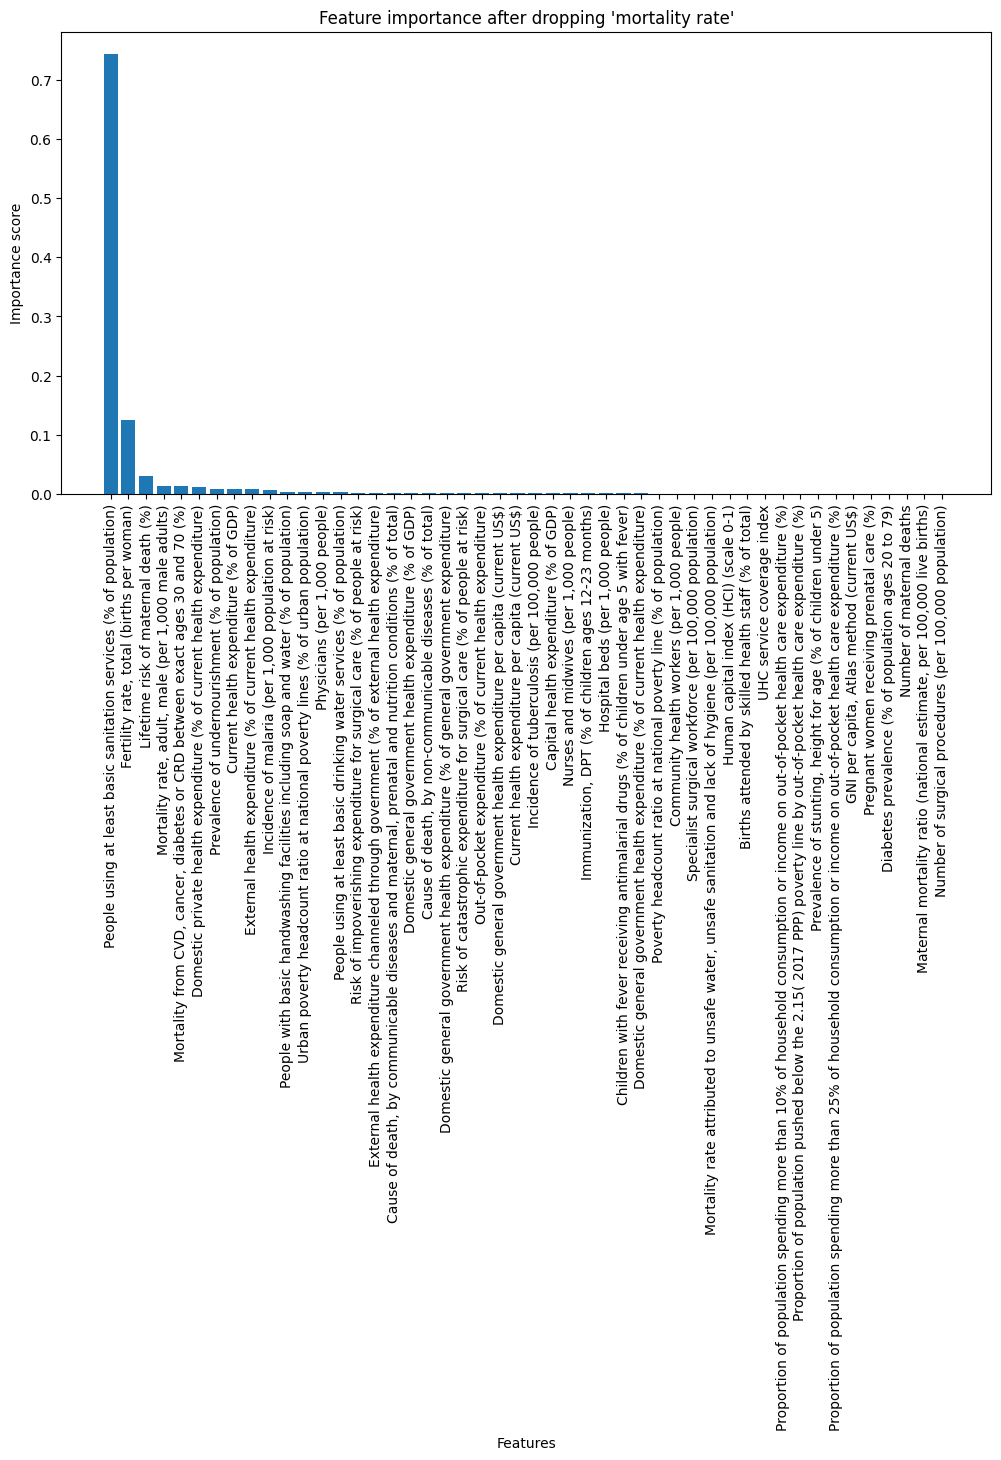

In [6]:
# Re run feature importance
rf_temp.fit(X_train, y_train)
feature_importance = rf_temp.feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_importance)), feature_importance[sorted_idx], align="center")
plt.xticks(range(len(feature_importance)), np.array(X_train.columns)[sorted_idx], rotation=90)
plt.title("Feature importance after dropping 'mortality rate'")
plt.xlabel("Features")
plt.ylabel("Importance score")
plt.show()

To ensure that no single feature overwhelmingly dictates predictions again, we re-ran the feature importance analysis. This time, it showed that 'people using at least basic sanitation services (% of population)' became the most influential predictor, contributing nearly 80% of the model’s decisions. Rather than removing this feature, which would discard useful information, we decided to transform it into categorical bins like low, medium, and high to retain its predictive power and also prevent the model from overly relying on one variable.

In [5]:
# Apply binning to 'basic sanitation' variable
def bin_sanitation(value):
    if value < 50:
        return "Low"
    elif 50 <= value < 75:
        return "Medium"
    else:
        return "High"

# Apply binning transformation
X_train["Sanitation_Binned"] = X_train["People using at least basic sanitation services (% of population)"].apply(bin_sanitation)
X_val["Sanitation_Binned"] = X_val["People using at least basic sanitation services (% of population)"].apply(bin_sanitation)

# Drop original sanitation column
X_train = X_train.drop(columns=["People using at least basic sanitation services (% of population)"])
X_val = X_val.drop(columns=["People using at least basic sanitation services (% of population)"])

# Convert categorical feature to numerical
X_train = pd.get_dummies(X_train, columns=["Sanitation_Binned"], drop_first=True)
X_val = pd.get_dummies(X_val, columns=["Sanitation_Binned"], drop_first=True)


In [6]:
# Apply 2% noise to validation data
numeric_features = X_train.select_dtypes(include=[np.number]).columns
X_val_noisy = X_val.copy()
for feature in numeric_features:
    noise = np.random.normal(loc=0, scale=0.02 * X_val[feature].std(), size=X_val[feature].shape)
    X_val_noisy[feature] += noise


We applied 2% gaussian noise to the validation dataset to introduce slight variability and prevent the model from memorizing patterns due to identical distributions in training and validation. This makes validation more challenging, and encouraging the model to generalize rather than overfit to fixed feature values.

In [7]:
# Model evaluation
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    model.fit(X_train, y_train)
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    metrics = {
        "Model": model_name,
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds)),
        "Validation RMSE": np.sqrt(mean_squared_error(y_val, val_preds)),
        "Train R2": r2_score(y_train, train_preds),
        "Validation R2": r2_score(y_val, val_preds),
    }

    print(f"{model_name} - Train RMSE: {metrics['Train RMSE']:.4f}, Validation RMSE: {metrics['Validation RMSE']:.4f}")
    return metrics


We chose our performance metrics to be RMSE and R² because they provide a clear assessment of model accuracy and generalization. RMSE will measure the magnitude of prediction errors in our target variable, making it easy to interpret how far predictions deviate from actual values. R² will evaluate how well the model explains variance in our target variable. The evaluate_model function trains a given random forest model and computes these metrics for both training and validation datasets. We can then identify potential overfitting or underfitting to help us select the best model variation

In [8]:
# Train & evaluate 3 RF models

# Variation 1 with default parameters
rf1 = RandomForestRegressor(n_estimators=50, random_state=42)
metrics1 = evaluate_model(rf1, X_train, y_train, X_val_noisy, y_val, "RF Default")

# Variation 2 with depth limited
rf2 = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
metrics2 = evaluate_model(rf2, X_train, y_train, X_val_noisy, y_val, "RF Depth Limited")

# Variation 3 with regularized model
rf3 = RandomForestRegressor(n_estimators=50, max_depth=3, min_samples_split=100, min_samples_leaf=50, random_state=42)
metrics3 = evaluate_model(rf3, X_train, y_train, X_val_noisy, y_val, "RF Regularized")

# Results
metrics_df = pd.DataFrame([metrics1, metrics2, metrics3])
print(metrics_df)


RF Default - Train RMSE: 0.5019, Validation RMSE: 1.1743
RF Depth Limited - Train RMSE: 1.0297, Validation RMSE: 1.5541
RF Regularized - Train RMSE: 2.5473, Validation RMSE: 2.6775
              Model  Train RMSE  Validation RMSE  Train R2  Validation R2
0        RF Default    0.501918         1.174296  0.997108       0.979485
1  RF Depth Limited    1.029675         1.554058  0.987829       0.964070
2    RF Regularized    2.547297         2.677519  0.925509       0.893344


The first variation used the default parameters, which allow trees to grow fully. It was selected to observe performance without constraints. The second variation introduced a maximum depth of 5, chosen to limit tree complexity, which helps to balance learning and generalization. The third variation applied stronger constraints, setting max_depth=3, and requiring at least 100 samples per split and 50 samples per leaf, it forces the model to generalize more effectively by reducing variance. This progression will help us to evaluate how different levels of regularization impact our predictive accuracy and generalization.


Based on the results, RF Regularized was selected as the best model due to the balanced performance.

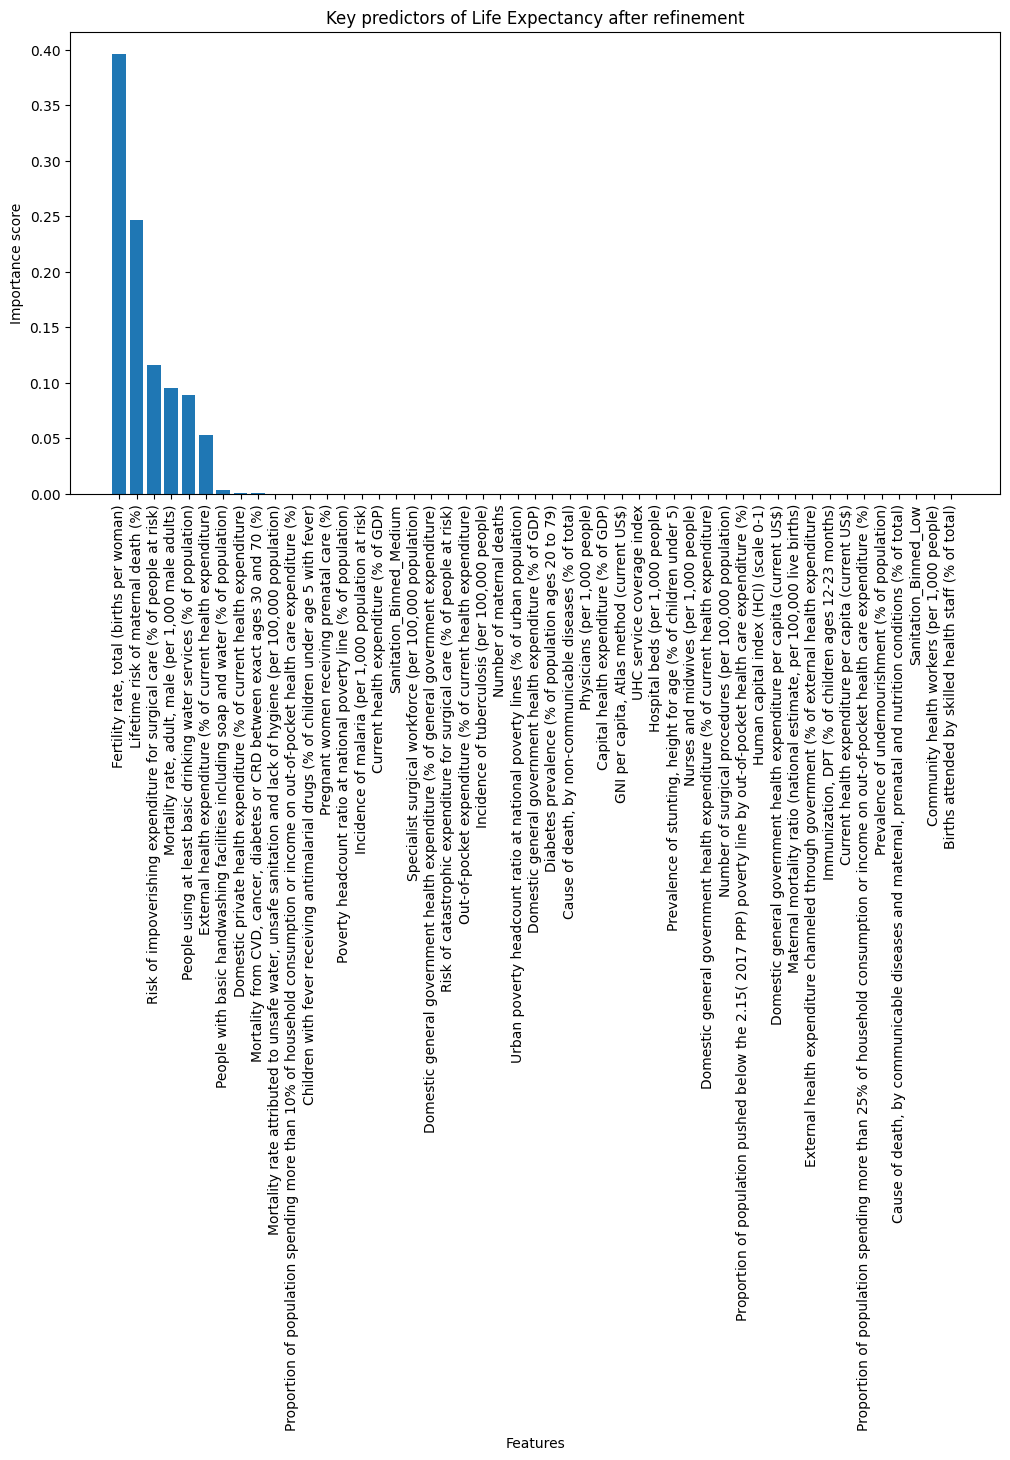

In [9]:
# Final feature importance analysis
feature_importance = rf3.feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_importance)), feature_importance[sorted_idx], align="center")
plt.xticks(range(len(feature_importance)), np.array(X_train.columns)[sorted_idx], rotation=90)
plt.title("Key predictors of Life Expectancy after refinement")
plt.xlabel("Features")
plt.ylabel("Importance score")
plt.show()


We ran a final feature importance analysis to make sure the model no longer relied on a single dominant feature and properly captured key predictors of our target variable. The plot show that fertility rate (births per woman) is the most influential factor with strongest correlation to life expectancy. Risk of impoverishing expenditure for surgical care as another critical predictor. Access to basic sanitation and safe drinking water also remained highly important. Unlike earlier versions, where a single feature dominated, the refined model now distributes importance across multiple variables with better generalization and reliability in predictions.

In [ ]:
# Load test dataset
test_data_path = "../Data/test_data.csv"
test_df = pd.read_csv(test_data_path)

# Convert to wide format
test_df_grouped = test_df.groupby(["country_name", "year", "series_name"], as_index=False)["value"].mean()
test_df_wide = test_df_grouped.pivot(index=["country_name", "year"], columns="series_name", values="value").reset_index()
test_df_wide.columns.name = None

# Test set features
X_test = test_df_wide[common_features]
y_test = test_df_wide[target_variable]
# Fill missing values
X_test.fillna(X_test.mean(), inplace=True)

# Apply binning transformation to test set
X_test["Sanitation_Binned"] = X_test["People using at least basic sanitation services (% of population)"].apply(bin_sanitation)

# Drop 'sanitation' column
X_test = X_test.drop(columns=["People using at least basic sanitation services (% of population)"])

# Convert categorical feature to numerical
X_test = pd.get_dummies(X_test, columns=["Sanitation_Binned"], drop_first=True)

# Ensure consistency
missing_cols = set(X_train.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0

X_test = X_test[X_train.columns]

# Evaluate the best model on test data
rf_final = RandomForestRegressor(n_estimators=50, max_depth=3, min_samples_split=100, min_samples_leaf=50, random_state=42)

metrics_test = evaluate_model(rf_final, X_train, y_train, X_test, y_test, "Final Model - Test Set")

# Results
metrics_test

Final Model - Test Set - Train RMSE: 2.5473, Validation RMSE: 2.3506


/var/folders/z6/vcd1nm395kx4c8bz82wk7hdw0000gn/T/ipykernel_4862/2293202547.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.fillna(X_test.mean(), inplace=True)
/var/folders/z6/vcd1nm395kx4c8bz82wk7hdw0000gn/T/ipykernel_4862/2293202547.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["Sanitation_Binned"] = X_test["People using at least basic sanitation services (% of population)"].apply(bin_sanitation)


{'Model': 'Final Model - Test Set',
 'Train RMSE': 2.5472971376410345,
 'Validation RMSE': 2.350644350385957,
 'Train R2': 0.9255093875446694,
 'Validation R2': 0.9173265979956529}